In [2]:
pip install torch torchvision numpy matplotlib tqdm scipy

Note: you may need to restart the kernel to use updated packages.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torch.autograd import grad
from torchvision.utils import save_image
import os
import torchvision.datasets as datasets
import torch.nn.utils as utils
from torch.optim import AdamW
import traceback


# Check GPU availability
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name(0)}")
    print(f"Total GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**2:.2f} MB")
else:
    print("CUDA not available, using CPU.")

# Ensure reproducibility
torch.manual_seed(42)

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Define dataset transformations (Reduced image size to 256x256 for efficiency)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

Using device: NVIDIA GeForce RTX 3050 Laptop GPU
Total GPU memory: 4095.50 MB
Using device: cuda


Total images loaded: 52899


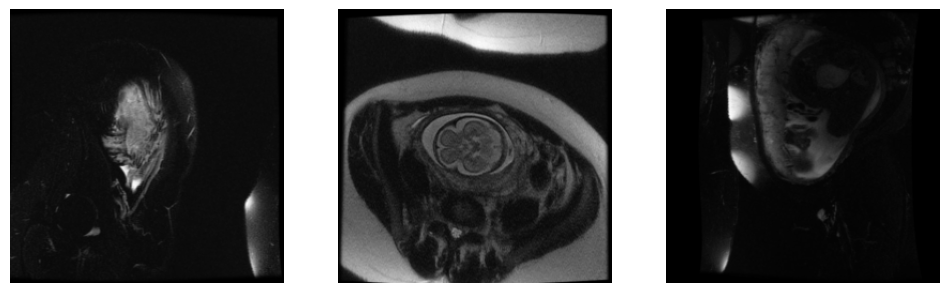

In [4]:
# Load Dataset
dataset = torchvision.datasets.ImageFolder(root=r"C:\Users\ASUS\Documents\minor Project\Implementation (WGAN)\Fetal_MRI_Dataset", transform=transform)
dataloader = DataLoader(dataset, batch_size = 16, shuffle=True, num_workers=2, pin_memory=True)

print(f"Total images loaded: {len(dataset)}")

# Display sample images
def show_images():
    real_batch = next(iter(dataloader))  # Get a batch of images
    images, _ = real_batch  # Extract images

    fig, axes = plt.subplots(1, 3, figsize=(12, 4)) 

    for i in range(3):  # Loop through first 3 images
        img = images[i].permute(1, 2, 0).cpu().numpy()  # Convert tensor to NumPy image
        img = img * 0.5 + 0.5  # Denormalize
        axes[i].imshow(img)
        axes[i].axis("off")

    plt.show()

show_images()

In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super(Generator, self).__init__()
        self.z_dim = z_dim

        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),  # Output: 4x4
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),  # Output: 8x8
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),  # Output: 16x16
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),  # Output: 32x32
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),  # Output: 64x64
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 4, 2, 1, bias=False),  # Output: 128x128
            nn.BatchNorm2d(16),
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 3, 4, 2, 1, bias=False),  # Output: 256x256
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

# Instantiate Generator
z_dim = 100
G = Generator(z_dim).to(device)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            utils.spectral_norm(nn.Conv2d(3, 64, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(64, 128, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(128, 256, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            utils.spectral_norm(nn.Conv2d(256, 512, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        )

    def forward(self, img):
        return self.model(img).view(-1)

D = Discriminator().to(device)

In [7]:
# Gradient Penalty Calculation
def compute_gradient_penalty(D, real_samples, fake_samples, device):
    batch_size, C, H, W = real_samples.shape
    alpha = torch.rand(batch_size, 1, 1, 1, device=device).expand_as(real_samples)

    interpolates = (alpha * real_samples + (1 - alpha) * fake_samples).requires_grad_(True)
    d_interpolates = D(interpolates)

    fake = torch.ones_like(d_interpolates, device=device)

    gradients = grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]

    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()

    return gradient_penalty

✅ Resumed training from epoch 410
Epoch [411/700] | D Loss: -0.0092 | G Loss: 2.7948
💾 Model saved at epoch 411
Epoch [412/700] | D Loss: -0.0165 | G Loss: 2.8048
💾 Model saved at epoch 412
Epoch [413/700] | D Loss: 0.0472 | G Loss: 2.7291
💾 Model saved at epoch 413
Epoch [414/700] | D Loss: -0.0575 | G Loss: 2.5898
💾 Model saved at epoch 414
Epoch [415/700] | D Loss: 0.0047 | G Loss: 2.6273
💾 Model saved at epoch 415
Epoch [416/700] | D Loss: -0.0057 | G Loss: 2.6241
💾 Model saved at epoch 416
Epoch [417/700] | D Loss: -0.0622 | G Loss: 2.5284
💾 Model saved at epoch 417
Epoch [418/700] | D Loss: -0.0276 | G Loss: 2.4091
💾 Model saved at epoch 418
Epoch [419/700] | D Loss: -0.0098 | G Loss: 2.5849
💾 Model saved at epoch 419


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999993..0.6430167].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.22252513].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.49560583].


Epoch [420/700] | D Loss: -0.0025 | G Loss: 2.4631


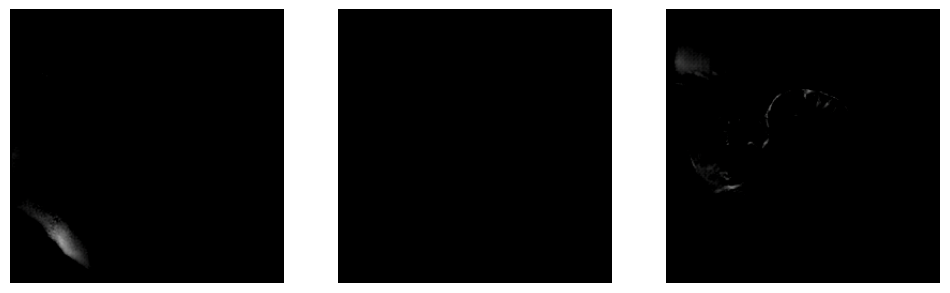

💾 Model saved at epoch 420
💾 Model saved at epoch 420
Epoch [421/700] | D Loss: 0.0167 | G Loss: 2.4730
💾 Model saved at epoch 421
Epoch [422/700] | D Loss: -0.0516 | G Loss: 2.6387
💾 Model saved at epoch 422
Epoch [423/700] | D Loss: -0.0260 | G Loss: 2.5820
💾 Model saved at epoch 423
Epoch [424/700] | D Loss: -0.0542 | G Loss: 2.5168
💾 Model saved at epoch 424
Epoch [425/700] | D Loss: -0.0070 | G Loss: 2.1949
💾 Model saved at epoch 425
Epoch [426/700] | D Loss: -0.0011 | G Loss: 2.2882
💾 Model saved at epoch 426
Epoch [427/700] | D Loss: 0.0106 | G Loss: 2.1696
💾 Model saved at epoch 427
Epoch [428/700] | D Loss: -0.0186 | G Loss: 2.0987
💾 Model saved at epoch 428
Epoch [429/700] | D Loss: -0.0419 | G Loss: 2.1678
💾 Model saved at epoch 429


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7951689].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.52873236].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.64972997].


Epoch [430/700] | D Loss: -0.0818 | G Loss: 2.1015


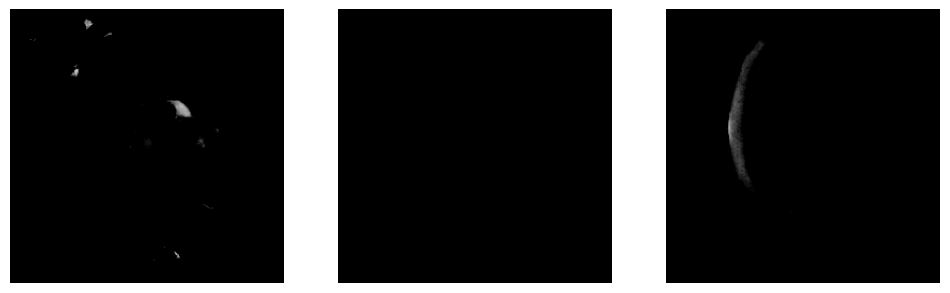

💾 Model saved at epoch 430
💾 Model saved at epoch 430
Epoch [431/700] | D Loss: -0.0058 | G Loss: 2.0655
💾 Model saved at epoch 431
Epoch [432/700] | D Loss: -0.0244 | G Loss: 2.0497
💾 Model saved at epoch 432
Epoch [433/700] | D Loss: -0.0094 | G Loss: 2.1368
💾 Model saved at epoch 433
Epoch [434/700] | D Loss: -0.0264 | G Loss: 2.2205
💾 Model saved at epoch 434
Epoch [435/700] | D Loss: -0.0000 | G Loss: 2.0551
💾 Model saved at epoch 435
Epoch [436/700] | D Loss: 0.0042 | G Loss: 1.9867
💾 Model saved at epoch 436
Epoch [437/700] | D Loss: 0.0390 | G Loss: 2.1828
💾 Model saved at epoch 437
Epoch [438/700] | D Loss: 0.0354 | G Loss: 1.8973
💾 Model saved at epoch 438
Epoch [439/700] | D Loss: 0.0058 | G Loss: 1.7956
💾 Model saved at epoch 439


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.10967491].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.50842935].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.47760096].


Epoch [440/700] | D Loss: -0.0555 | G Loss: 1.8283


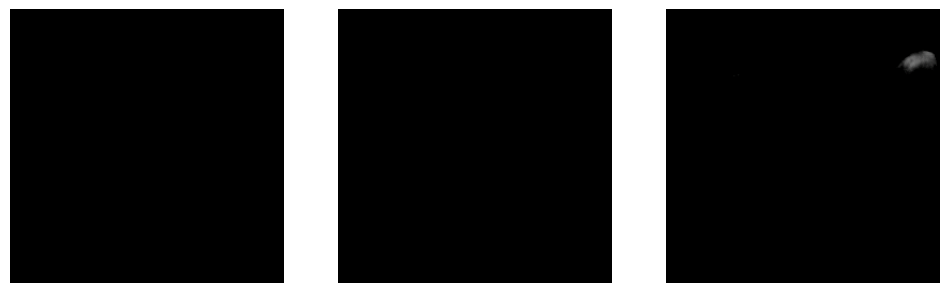

💾 Model saved at epoch 440
💾 Model saved at epoch 440
Epoch [441/700] | D Loss: -0.0210 | G Loss: 1.8019
💾 Model saved at epoch 441
Epoch [442/700] | D Loss: -0.0205 | G Loss: 1.8270
💾 Model saved at epoch 442
Epoch [443/700] | D Loss: -0.0043 | G Loss: 1.7316
💾 Model saved at epoch 443
Epoch [444/700] | D Loss: 0.0375 | G Loss: 1.8895
💾 Model saved at epoch 444
Epoch [445/700] | D Loss: 0.0114 | G Loss: 1.7530
💾 Model saved at epoch 445
Epoch [446/700] | D Loss: 0.0086 | G Loss: 1.7689
💾 Model saved at epoch 446
Epoch [447/700] | D Loss: 0.0479 | G Loss: 1.7354
💾 Model saved at epoch 447
Epoch [448/700] | D Loss: 0.0665 | G Loss: 1.6237
💾 Model saved at epoch 448
Epoch [449/700] | D Loss: -0.0122 | G Loss: 1.8459
💾 Model saved at epoch 449


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.75092506].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7863927].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.51617193].


Epoch [450/700] | D Loss: 0.0371 | G Loss: 1.7103


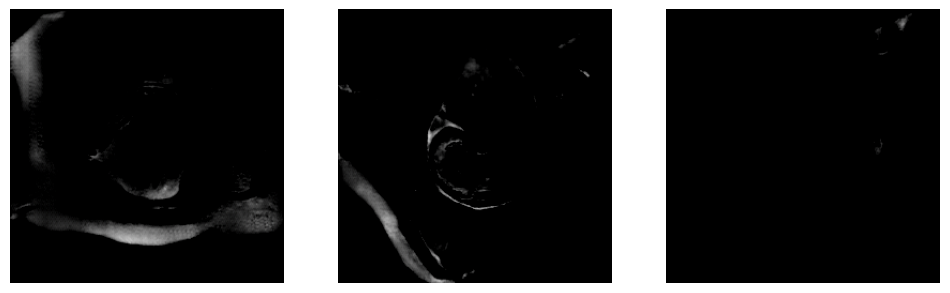

💾 Model saved at epoch 450
💾 Model saved at epoch 450
Epoch [451/700] | D Loss: -0.0487 | G Loss: 1.6771
💾 Model saved at epoch 451
Epoch [452/700] | D Loss: -0.0067 | G Loss: 1.5500
💾 Model saved at epoch 452
Epoch [453/700] | D Loss: -0.0438 | G Loss: 1.6002
💾 Model saved at epoch 453
Epoch [454/700] | D Loss: -0.0223 | G Loss: 1.5493
💾 Model saved at epoch 454
Epoch [455/700] | D Loss: -0.1128 | G Loss: 1.4379
💾 Model saved at epoch 455
Epoch [456/700] | D Loss: 0.0124 | G Loss: 1.2700
💾 Model saved at epoch 456
Epoch [457/700] | D Loss: 0.0334 | G Loss: 1.2959
💾 Model saved at epoch 457
Epoch [458/700] | D Loss: -0.0493 | G Loss: 1.2847
💾 Model saved at epoch 458
Epoch [459/700] | D Loss: 0.0214 | G Loss: 1.3970
💾 Model saved at epoch 459


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.96037304].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.024939029].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99999994..0.7930459].


Epoch [460/700] | D Loss: -0.0294 | G Loss: 1.5704


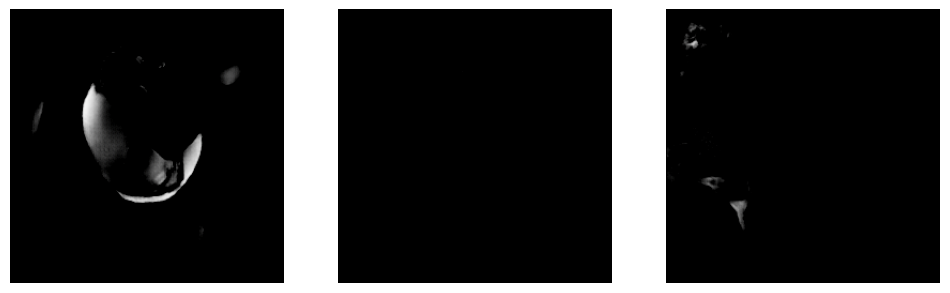

💾 Model saved at epoch 460
💾 Model saved at epoch 460
Epoch [461/700] | D Loss: 0.0245 | G Loss: 1.2367
💾 Model saved at epoch 461
Epoch [462/700] | D Loss: -0.0299 | G Loss: 1.1947
💾 Model saved at epoch 462
Epoch [463/700] | D Loss: -0.0080 | G Loss: 1.2885
💾 Model saved at epoch 463
Epoch [464/700] | D Loss: -0.0141 | G Loss: 1.1381
💾 Model saved at epoch 464
Epoch [465/700] | D Loss: 0.0273 | G Loss: 1.1961
💾 Model saved at epoch 465
Epoch [466/700] | D Loss: 0.0078 | G Loss: 1.3103
💾 Model saved at epoch 466
Epoch [467/700] | D Loss: 0.0024 | G Loss: 1.0133
💾 Model saved at epoch 467
Epoch [468/700] | D Loss: -0.0113 | G Loss: 1.1540
💾 Model saved at epoch 468
Epoch [469/700] | D Loss: -0.0116 | G Loss: 1.0823
💾 Model saved at epoch 469


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8156961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9970516..0.9296848].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8073571].


Epoch [470/700] | D Loss: 0.0134 | G Loss: 1.1880


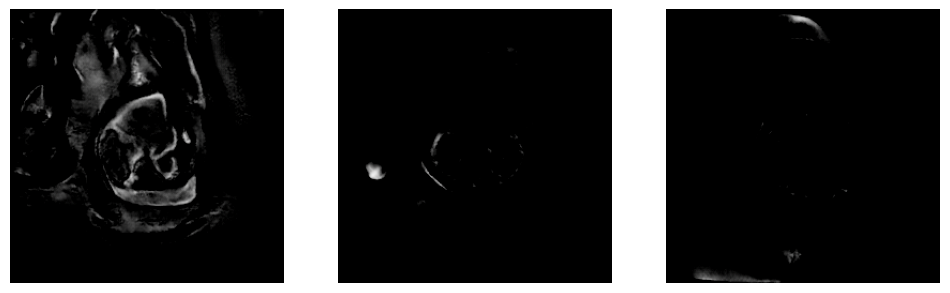

💾 Model saved at epoch 470
💾 Model saved at epoch 470
Epoch [471/700] | D Loss: -0.0229 | G Loss: 1.1036
💾 Model saved at epoch 471
Epoch [472/700] | D Loss: -0.0476 | G Loss: 1.0760
💾 Model saved at epoch 472
Epoch [473/700] | D Loss: -0.0768 | G Loss: 0.9353
💾 Model saved at epoch 473
Epoch [474/700] | D Loss: 0.0134 | G Loss: 1.0554
💾 Model saved at epoch 474
Epoch [475/700] | D Loss: -0.0059 | G Loss: 0.9446
💾 Model saved at epoch 475
Epoch [476/700] | D Loss: -0.0054 | G Loss: 0.9590
💾 Model saved at epoch 476
Epoch [477/700] | D Loss: -0.0300 | G Loss: 0.7319
💾 Model saved at epoch 477
Epoch [478/700] | D Loss: -0.0411 | G Loss: 0.7416
💾 Model saved at epoch 478
Epoch [479/700] | D Loss: 0.0103 | G Loss: 0.7602
💾 Model saved at epoch 479


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.90723276].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9651538].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.73893756].


Epoch [480/700] | D Loss: -0.0209 | G Loss: 0.6669


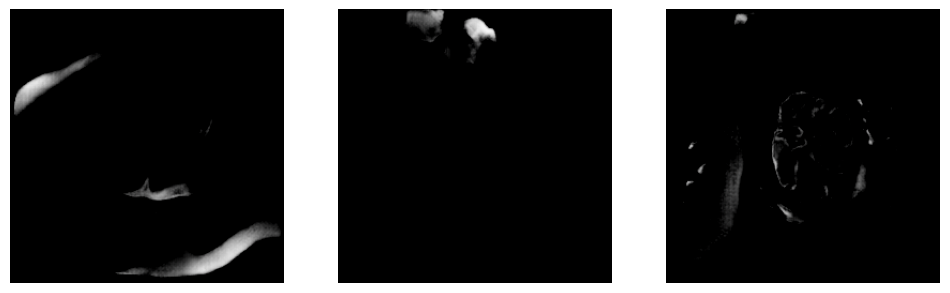

💾 Model saved at epoch 480
💾 Model saved at epoch 480
Epoch [481/700] | D Loss: -0.0304 | G Loss: 0.5853
💾 Model saved at epoch 481
Epoch [482/700] | D Loss: -0.0169 | G Loss: 0.8183
💾 Model saved at epoch 482
Epoch [483/700] | D Loss: -0.0484 | G Loss: 0.4778
💾 Model saved at epoch 483
Epoch [484/700] | D Loss: 0.0091 | G Loss: 0.6827
💾 Model saved at epoch 484
Epoch [485/700] | D Loss: 0.0011 | G Loss: 0.6596
💾 Model saved at epoch 485
Epoch [486/700] | D Loss: 0.0234 | G Loss: 0.7703
💾 Model saved at epoch 486
Epoch [487/700] | D Loss: -0.0226 | G Loss: 0.3313
💾 Model saved at epoch 487
Epoch [488/700] | D Loss: -0.0206 | G Loss: 0.2407
💾 Model saved at epoch 488
Epoch [489/700] | D Loss: 0.0060 | G Loss: 0.3900
💾 Model saved at epoch 489


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5647192].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.83106136].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9634044].


Epoch [490/700] | D Loss: -0.0051 | G Loss: 0.2785


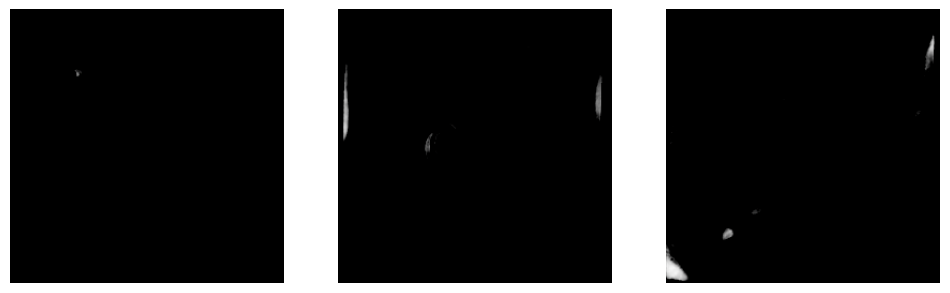

💾 Model saved at epoch 490
💾 Model saved at epoch 490
Epoch [491/700] | D Loss: -0.0024 | G Loss: 0.1836
💾 Model saved at epoch 491
Epoch [492/700] | D Loss: 0.0328 | G Loss: 0.2777
💾 Model saved at epoch 492
Epoch [493/700] | D Loss: -0.0416 | G Loss: 0.3272
💾 Model saved at epoch 493
Epoch [494/700] | D Loss: 0.0240 | G Loss: 0.2762
💾 Model saved at epoch 494
Epoch [495/700] | D Loss: -0.0222 | G Loss: 0.2828
💾 Model saved at epoch 495
Epoch [496/700] | D Loss: -0.0138 | G Loss: 0.3275
💾 Model saved at epoch 496
Epoch [497/700] | D Loss: -0.0104 | G Loss: 0.3092
💾 Model saved at epoch 497
Epoch [498/700] | D Loss: 0.0091 | G Loss: 0.3650
💾 Model saved at epoch 498
Epoch [499/700] | D Loss: -0.0342 | G Loss: 0.3093
💾 Model saved at epoch 499


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..-0.22609562].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8170613].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8539512].


Epoch [500/700] | D Loss: -0.0146 | G Loss: 0.1748


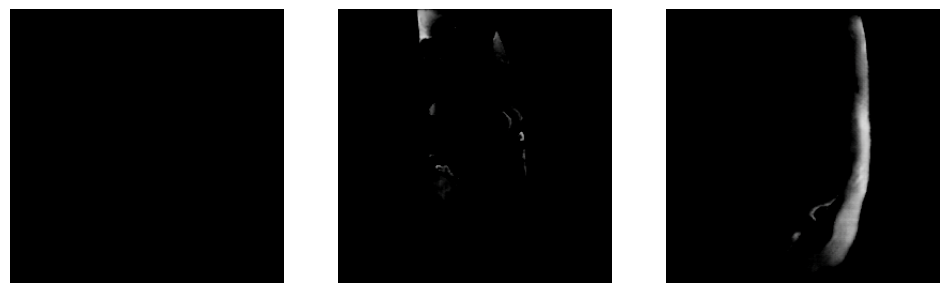

💾 Model saved at epoch 500
💾 Model saved at epoch 500
Epoch [501/700] | D Loss: 0.0065 | G Loss: 0.2574
💾 Model saved at epoch 501
Epoch [502/700] | D Loss: 0.0030 | G Loss: 0.2758
💾 Model saved at epoch 502
Epoch [503/700] | D Loss: 0.0081 | G Loss: 0.0308
💾 Model saved at epoch 503
Epoch [504/700] | D Loss: -0.0006 | G Loss: 0.1581
💾 Model saved at epoch 504
Epoch [505/700] | D Loss: 0.3980 | G Loss: 0.0784
💾 Model saved at epoch 505
Epoch [506/700] | D Loss: -0.0034 | G Loss: 0.0557
💾 Model saved at epoch 506
Epoch [507/700] | D Loss: -0.0850 | G Loss: -0.0462
💾 Model saved at epoch 507
Epoch [508/700] | D Loss: -0.0469 | G Loss: -0.0270
💾 Model saved at epoch 508
Epoch [509/700] | D Loss: 0.0469 | G Loss: 0.0075
💾 Model saved at epoch 509


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.055244606].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8675345].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999958..-0.09563275].


Epoch [510/700] | D Loss: 0.0132 | G Loss: -0.0469


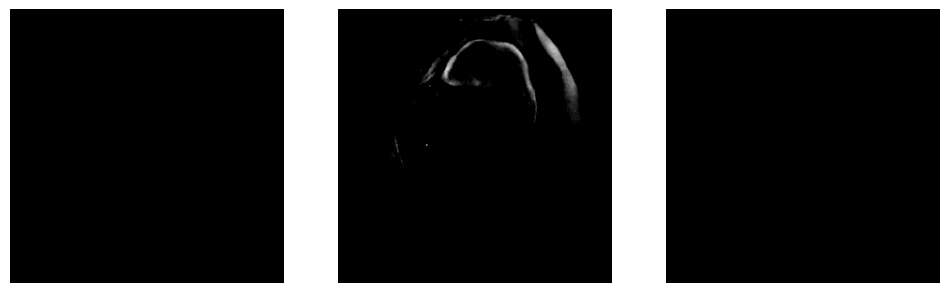

💾 Model saved at epoch 510
💾 Model saved at epoch 510
Epoch [511/700] | D Loss: -0.0046 | G Loss: 0.0127
💾 Model saved at epoch 511
Epoch [512/700] | D Loss: 0.1368 | G Loss: -0.0575
💾 Model saved at epoch 512
Epoch [513/700] | D Loss: -0.0001 | G Loss: -0.1012
💾 Model saved at epoch 513
Epoch [514/700] | D Loss: 0.0140 | G Loss: -0.1111
💾 Model saved at epoch 514
Epoch [515/700] | D Loss: -0.0098 | G Loss: -0.0588
💾 Model saved at epoch 515
Epoch [516/700] | D Loss: 0.0063 | G Loss: -0.2915
💾 Model saved at epoch 516
Epoch [517/700] | D Loss: 0.0269 | G Loss: -0.2961
💾 Model saved at epoch 517
Epoch [518/700] | D Loss: -0.0310 | G Loss: -0.3693
💾 Model saved at epoch 518
Epoch [519/700] | D Loss: -0.0385 | G Loss: -0.5966
💾 Model saved at epoch 519


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8271745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5299101].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.92653424].


Epoch [520/700] | D Loss: -0.0224 | G Loss: -0.4343


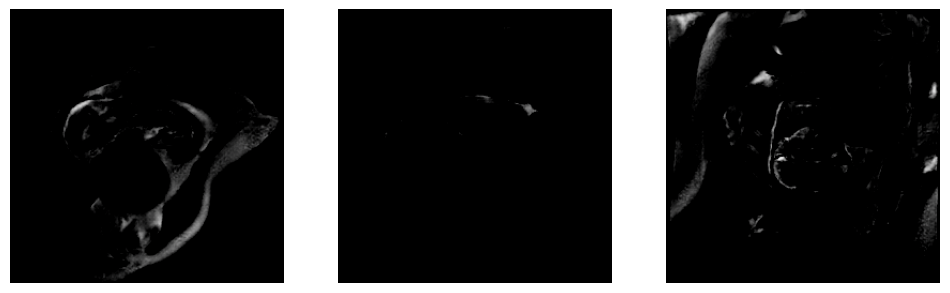

💾 Model saved at epoch 520
💾 Model saved at epoch 520
Epoch [521/700] | D Loss: -0.0139 | G Loss: -0.5064
💾 Model saved at epoch 521
Epoch [522/700] | D Loss: -0.0176 | G Loss: -0.5847
💾 Model saved at epoch 522
Epoch [523/700] | D Loss: -0.0373 | G Loss: -0.5096
💾 Model saved at epoch 523
Epoch [524/700] | D Loss: 0.0244 | G Loss: -0.6107
💾 Model saved at epoch 524
Epoch [525/700] | D Loss: -0.0265 | G Loss: -0.5505
💾 Model saved at epoch 525
Epoch [526/700] | D Loss: -0.0676 | G Loss: -0.5341
💾 Model saved at epoch 526
Epoch [527/700] | D Loss: -0.0174 | G Loss: -0.5850
💾 Model saved at epoch 527
Epoch [528/700] | D Loss: 0.0162 | G Loss: -0.6994
💾 Model saved at epoch 528
Epoch [529/700] | D Loss: -0.0398 | G Loss: -0.7127
💾 Model saved at epoch 529


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99999994..0.77629167].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9546673].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9555411].


Epoch [530/700] | D Loss: 0.0139 | G Loss: -0.6963


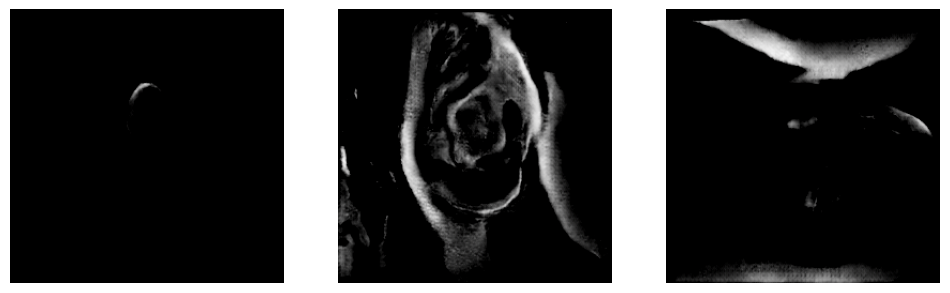

💾 Model saved at epoch 530
💾 Model saved at epoch 530
Epoch [531/700] | D Loss: 0.0149 | G Loss: -0.7305
💾 Model saved at epoch 531
Epoch [532/700] | D Loss: 0.0045 | G Loss: -0.6534
💾 Model saved at epoch 532
Epoch [533/700] | D Loss: -0.0332 | G Loss: -0.6969
💾 Model saved at epoch 533
Epoch [534/700] | D Loss: 0.0132 | G Loss: -0.6833
💾 Model saved at epoch 534
Epoch [535/700] | D Loss: 0.0008 | G Loss: -0.7976
💾 Model saved at epoch 535
Epoch [536/700] | D Loss: 0.2508 | G Loss: -0.7880
💾 Model saved at epoch 536
Epoch [537/700] | D Loss: 0.0368 | G Loss: -0.9268
💾 Model saved at epoch 537
Epoch [538/700] | D Loss: -0.0235 | G Loss: -0.9387
💾 Model saved at epoch 538
Epoch [539/700] | D Loss: 0.0865 | G Loss: -0.9613
💾 Model saved at epoch 539


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.40544137].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.31783515].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9249114].


Epoch [540/700] | D Loss: -0.0114 | G Loss: -1.0558


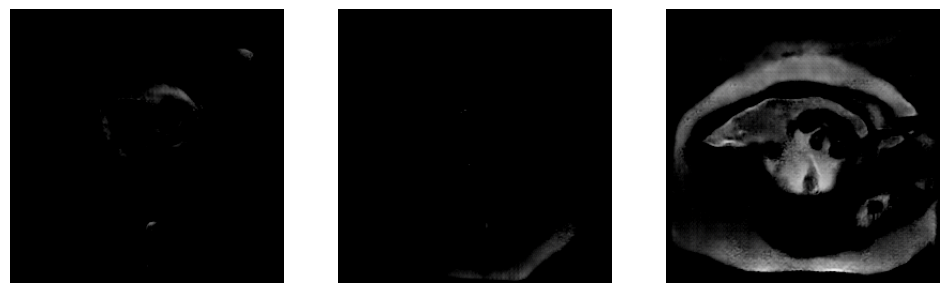

💾 Model saved at epoch 540
💾 Model saved at epoch 540
Epoch [541/700] | D Loss: -0.0281 | G Loss: -1.0940
💾 Model saved at epoch 541
Epoch [542/700] | D Loss: -0.0284 | G Loss: -1.0844
💾 Model saved at epoch 542
Epoch [543/700] | D Loss: -0.0457 | G Loss: -1.0661
💾 Model saved at epoch 543
Epoch [544/700] | D Loss: 0.1034 | G Loss: -1.2082
💾 Model saved at epoch 544
Epoch [545/700] | D Loss: 0.0472 | G Loss: -1.2254
💾 Model saved at epoch 545
Epoch [546/700] | D Loss: -0.0615 | G Loss: -1.2731
💾 Model saved at epoch 546
Epoch [547/700] | D Loss: -0.0618 | G Loss: -1.2159
💾 Model saved at epoch 547
Epoch [548/700] | D Loss: -0.0119 | G Loss: -1.4797
💾 Model saved at epoch 548
Epoch [549/700] | D Loss: -0.0085 | G Loss: -1.4015
💾 Model saved at epoch 549


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.1860449].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9501625].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.91801953].


Epoch [550/700] | D Loss: 0.0015 | G Loss: -1.3807


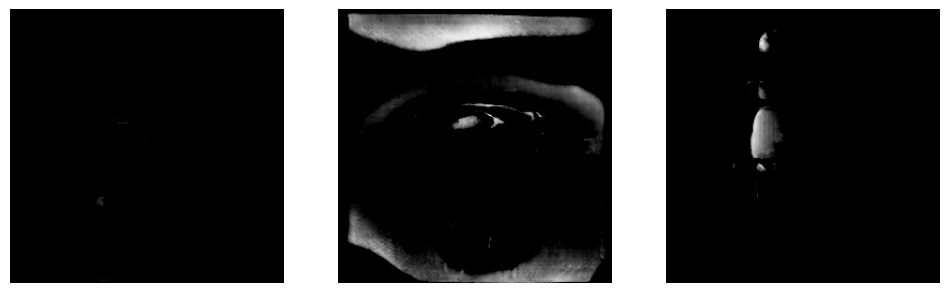

💾 Model saved at epoch 550
💾 Model saved at epoch 550
Epoch [551/700] | D Loss: -0.0225 | G Loss: -1.3915
💾 Model saved at epoch 551
Epoch [552/700] | D Loss: -0.0505 | G Loss: -1.5953
💾 Model saved at epoch 552
Epoch [553/700] | D Loss: -0.0094 | G Loss: -1.4580
💾 Model saved at epoch 553
Epoch [554/700] | D Loss: 0.0569 | G Loss: -1.6927
💾 Model saved at epoch 554
Epoch [555/700] | D Loss: -0.0191 | G Loss: -1.7074
💾 Model saved at epoch 555
Epoch [556/700] | D Loss: 0.0602 | G Loss: -1.6739
💾 Model saved at epoch 556
Epoch [557/700] | D Loss: -0.0078 | G Loss: -1.7490
💾 Model saved at epoch 557


KeyboardInterrupt: 

In [21]:
# Define Paths (Set these before running)
model_dir = "256_saved_epocs"  # Example: "WGANs_Colab/WGAN256/saved_models"
image_dir = "256_gen_images"  # Example: "WGANs_Colab/WGAN256/generated_images"
checkpoint_path = r"C:\Users\ASUS\Documents\minor Project\Implementation (WGAN)\WGAN_Local\256_saved_epocs\epoch_410.pth"  # Example: os.path.join(model_dir, "epoch_20.pth")

# Create directories if they don't exist
os.makedirs(model_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

# Hyperparameters
z_dim = 100
epochs = 700
batch_size = 64
lambda_gp = 10
critic_iterations = 5 
learning_rate_G = 0.00005  # Slightly higher for Generator
learning_rate_D = 0.00005  # Lower for Discriminator
weight_decay = 0.001  # Helps regularization
num_workers = 2  # Use multi-threading
pin_memory = True  # Faster memory transfer



# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize models (Ensure Generator & Discriminator are defined)
G = Generator(z_dim).to(device)
D = Discriminator().to(device)

# Optimizers
# optimizer_G = AdamW(G.parameters(), lr=learning_rate_G, betas=(0.5, 0.9), weight_decay=weight_decay)
# optimizer_D = AdamW(D.parameters(), lr=learning_rate_D, betas=(0.5, 0.9), weight_decay=weight_decay)

optimizer_G = AdamW(G.parameters(), lr=learning_rate_G, betas=(0.0, 0.9))
optimizer_D = AdamW(D.parameters(), lr=learning_rate_D, betas=(0.0, 0.9))

# Resume Training if Checkpoint Exists
start_epoch = 0
if checkpoint_path and os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    G.load_state_dict(checkpoint['generator_state_dict'])
    D.load_state_dict(checkpoint['discriminator_state_dict'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    start_epoch = checkpoint['epoch']
    print(f"✅ Resumed training from epoch {start_epoch}")

def save_model(epoch):
    """Saves model & optimizer states to prevent loss in case of crashes."""
    model_path = os.path.join(model_dir, f"epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch + 1,
        'generator_state_dict': G.state_dict(),
        'discriminator_state_dict': D.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'loss_G': loss_G.item(),
        'loss_D': loss_D.item(),
    }, model_path)
    print(f"💾 Model saved at epoch {epoch+1}")


# Save and Display Individual Images
def save_and_display(epoch, gen_imgs):
    """Saves images and displays them individually while maintaining aspect ratio."""
    
    # Save generated images
    for i in range(3):  # Save first 3 images
        image_path = os.path.join(image_dir, f"epoch_{epoch+1}_img{i+1}.png")
        save_image(gen_imgs[i], image_path, normalize=True)

    # Display individual images
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # Create a row of 3 images
    for i in range(3):
        img = gen_imgs[i].cpu().detach().permute(1, 2, 0)  # Convert (C, H, W) → (H, W, C)
        axes[i].imshow(img)  # Use grayscale colormap if needed
        axes[i].axis("off")  # Hide axes
    
    plt.show()


    # Save model
    save_model(epoch)

# Training Loop with Crash Recovery
for epoch in range(start_epoch, epochs):
    try:
        for i, (real_imgs, _) in enumerate(dataloader):
            real_imgs = real_imgs.to(device)

            # Train Discriminator
            optimizer_D.zero_grad()
            z = torch.randn(real_imgs.shape[0], z_dim, 1, 1, device=device)
            fake_imgs = G(z).detach()
            real_loss = D(real_imgs).mean()
            fake_loss = D(fake_imgs.detach()).mean()
            gradient_penalty = compute_gradient_penalty(D, real_imgs, fake_imgs, device)
            loss_D = fake_loss - real_loss + lambda_gp * gradient_penalty
            loss_D.backward()
            optimizer_D.step()

            # Train Generator
            if i % critic_iterations == 0:
                optimizer_G.zero_grad()
                z = torch.randn(real_imgs.shape[0], z_dim, 1, 1, device=device)
                gen_imgs = G(z)
                loss_G = -D(gen_imgs).mean()
                loss_G.backward()  # ❌ Removed retain_graph=True
                optimizer_G.step()

        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

        # Save and Display Every 10 Epochs
        if (epoch + 1) % 10 == 0:
            save_and_display(epoch, gen_imgs)

        # Save model every epoch to prevent loss in case of crashes
        save_model(epoch)

    except Exception as e:
        print(f"❌ Training interrupted at epoch {epoch+1}: {e}")
        traceback.print_exc()
        save_model(epoch)
        break


In [13]:
import torch

checkpoint_path = r"C:\Users\ASUS\Documents\minor Project\Implementation (WGAN)\WGAN_Local\256_saved_epocs\epoch_328.pth"  # Update path if needed
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

print(checkpoint.keys())  # Check available keys


dict_keys(['epoch', 'generator_state_dict', 'discriminator_state_dict', 'optimizer_G_state_dict', 'optimizer_D_state_dict', 'loss_G', 'loss_D'])


In [8]:
import torch
import matplotlib.pyplot as plt

def generate_images_from_checkpoint(generator, checkpoint_path, latent_dim=100, num_images=5):
    """
    Loads a saved WGAN generator model and generates images, displaying them individually while maintaining aspect ratio.
    
    Args:
        generator (torch.nn.Module): The generator model instance.
        checkpoint_path (str): Path to the saved checkpoint file.
        latent_dim (int): Latent space dimensionality.
        num_images (int): Number of images to generate.
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

    # Load the generator weights
    if "generator_state_dict" in checkpoint:
        generator.load_state_dict(checkpoint["generator_state_dict"])
    else:
        raise KeyError("Key 'generator_state_dict' not found in checkpoint.")

    generator.eval()  # Set model to evaluation mode

    # Generate random latent vectors
    z = torch.randn(num_images, latent_dim, 1, 1)  # Correct shape for ConvTranspose2d

    # Generate images
    with torch.no_grad():
        generated_images = generator(z)

    generated_images = (generated_images + 1) / 2  # Scale [-1, 1] → [0, 1]

    # Display each image individually with proper aspect ratio
    for i in range(num_images):
        img = generated_images[i].detach().cpu().numpy().transpose(1, 2, 0)  # Convert (C, H, W) → (H, W, C)

        fig, ax = plt.subplots(figsize=(2.56, 2.56))  # Maintain 256x256 aspect ratio
        ax.imshow(img)
        ax.axis('off')  # Remove axis
        plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Remove padding
        plt.margins(0)  # Remove extra space
        plt.show()

# Example usage
checkpoint_path = r"C:\Users\ASUS\Documents\minor Project\Implementation (WGAN)\WGAN_Local\256_saved_epocs\epoch_510.pth"  # Adjust to your file

generator = Generator()  # Define the generator architecture here
generate_images_from_checkpoint(generator, checkpoint_path, latent_dim=100, num_images=5)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ASUS\\Documents\\minor Project\\Implementation (WGAN)\\WGAN_Local\\256_saved_epocs\\epoch_510.pth'